# S&P 500 Equity+Option - IV-RV Spread: Causal DML Sensitivity Analysis

Does the negative association between the implied-realized volatility spread
and future equity returns remain after adjustment for observed confounders?
This notebook applies DML to `ivrv_spread` across a retrospective panel drawn
from the current-constituent roster, with option-derived features at daily
frequency.

**Treatment rationale**: The IV-RV spread captures option mispricing - when
implied volatility exceeds realized, options are "expensive." Realized
volatility (20d), equity momentum (21d), and risk-reversal skew (25-delta,
30d) confound this relationship because all three co-move with investor fear
and positioning.

**Learning Objectives**:
- Keep the sealed holdout outside an exploratory causal analysis
- Cross-fit a panel by complete decision time with a time-based embargo
- Compare the adjusted estimate with naive OLS and a block-permutation null

**Book Reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`

## Identifying Assumptions

DML identifies a causal effect only if three assumptions hold:
1. **Conditional ignorability**: No unobserved confounders - all backdoor paths
   between treatment and outcome are blocked by the observed confounders.
2. **Overlap (positivity)**: Every unit has a nonzero probability of receiving
   any treatment level, conditional on confounders.
3. **SUTVA**: One unit's treatment doesn't affect another's outcome.

These are untestable. The refutation test below provides indirect evidence
but cannot prove the assumptions hold.

In [1]:
"""Causal DML walk-forward estimation with refutation tests."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from case_studies.utils.causal import (
    classify_refutation,
    embargo_from_buffer,
    format_dml_summary,
    register_causal_run,
    run_dml_analysis,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
RANDOM_SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 50000
N_PLACEBO = 100

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)

setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

causal_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "causal_dml")
dml_cfg = causal_configs[0]

for key, val in [
    ("n_folds", CV_FOLDS),
    ("n_placebo", N_PLACEBO),
    ("max_samples", MAX_SAMPLES),
    ("seed", RANDOM_SEED),
]:
    if dml_cfg.get(key, val) != val:
        dml_cfg[key] = val

CV_FOLDS = dml_cfg.get("n_folds", 5)
N_PLACEBO = dml_cfg.get("n_placebo", 100)
MAX_SAMPLES = dml_cfg.get("max_samples", 50000)
RANDOM_SEED = dml_cfg.get("seed", 42)

print(f"DML config: {dml_cfg['config_name']}")

DML config: dml


The case-study configuration defines the treatment and confounders. Keeping
these choices visible makes the conditional estimand explicit.

In [4]:
causal_cfg = setup.get("causal", {})
TREATMENT_COL = causal_cfg.get("treatment", "")
CONFOUNDER_COLS = causal_cfg.get("confounders", [])
DML_METHOD = causal_cfg.get("method", "walk_forward_dml")

if not TREATMENT_COL:
    raise ValueError(
        f"No causal.treatment in {CASE_STUDY_ID}/setup.yaml. "
        "Add a 'causal:' section with treatment and confounders."
    )

set_global_seeds(RANDOM_SEED)

print("Causal DML Configuration:")
print(f"  Case study: {CASE_STUDY_ID}")
print(f"  Treatment: {TREATMENT_COL}")
print(f"  Outcome: {PRIMARY_LABEL}")
print(f"  Confounders: {CONFOUNDER_COLS}")
print(f"  CV folds: {CV_FOLDS}")
print(f"  Placebo reps: {N_PLACEBO}")

Causal DML Configuration:
  Case study: sp500_equity_option_analytics
  Treatment: ivrv_spread
  Outcome: fwd_ret_5d
  Confounders: ['rv_20', 'mom_21d', 'skew_rr_30_25d']
  CV folds: 5
  Placebo reps: 100


## 1. Load Artifacts

Load pre-computed features, temporal features, and labels using the
shared modeling infrastructure.

In [5]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_cols = mds.entity_cols

# Verify treatment and confounders are in features
available = set(dataset.columns)
assert TREATMENT_COL in available, (
    f"Treatment '{TREATMENT_COL}' not found in features: {sorted(available)}"
)

missing_conf = [c for c in CONFOUNDER_COLS if c not in available]
if missing_conf:
    print(f"WARNING: Missing confounders {missing_conf}, dropping them")
    CONFOUNDER_COLS = [c for c in CONFOUNDER_COLS if c in available]

assert len(CONFOUNDER_COLS) >= 1, "Need at least 1 confounder for DML"

print(f"\nDataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Label: {label_col} | Date: {date_col} | Entities: {entity_cols}")


Dataset: 527,968 rows x 48 features
Label: fwd_ret_5d | Date: timestamp | Entities: ['symbol']


## 2. Prepare Analysis Data

Convert to pandas, seal the holdout, sort by time and entity, and retain the
most recent complete decision times when the production cap applies.

> **Population scope**: The source universe is a current-constituent roster,
> not point-in-time S&P 500 membership. Firms removed from the index before
> the roster date are absent. The estimate therefore describes this
> retrospective roster during the development period; it does not generalize
> to the historical index-membership process or a prospective S&P 500
> population.

In [6]:
analysis_cols = [date_col] + entity_cols + [TREATMENT_COL, label_col] + CONFOUNDER_COLS
analysis_cols = list(dict.fromkeys(analysis_cols))  # deduplicate

merged_clean = (
    dataset.select([c for c in analysis_cols if c in available])
    .drop_nulls()
    .sort(date_col)
    .to_pandas()
)

The forward-label buffer closes the development sample early enough that no
outcome interval crosses into the sealed holdout.

In [7]:
EMBARGO_PERIODS = embargo_from_buffer(mds.label_buffer)
BLOCK_SIZE = EMBARGO_PERIODS
HOLDOUT_START = pd.Timestamp(setup["evaluation"]["holdout_start"])
DEVELOPMENT_CUTOFF = HOLDOUT_START - pd.Timedelta(mds.label_buffer)

# Labels at or after this cutoff can overlap the sealed holdout return window.
merged_clean = merged_clean.loc[merged_clean[date_col] < DEVELOPMENT_CUTOFF].copy()

sort_cols = [date_col, *entity_cols]
merged_clean = merged_clean.sort_values(sort_cols).reset_index(drop=True)

if entity_cols and merged_clean.duplicated([date_col, entity_cols[0]]).any():
    raise ValueError("Causal panel must contain at most one row per decision time and entity")

When a row cap is active, retain whole recent cross-sections so that sample
construction cannot cut through a decision time.

In [8]:
if MAX_SAMPLES > 0 and len(merged_clean) > MAX_SAMPLES:
    date_counts = merged_clean.groupby(date_col, sort=True).size()
    reverse_cumulative = date_counts.iloc[::-1].cumsum()
    selected_dates = reverse_cumulative[reverse_cumulative <= MAX_SAMPLES].index
    if len(selected_dates) == 0:
        raise ValueError(f"MAX_SAMPLES={MAX_SAMPLES:,} cannot fit one complete decision time")
    print(
        f"Taking {len(selected_dates):,} most recent complete decision times "
        f"({int(date_counts.loc[selected_dates].sum()):,} rows) from {len(merged_clean):,}"
    )
    merged_clean = merged_clean.loc[merged_clean[date_col].isin(selected_dates)].reset_index(
        drop=True
    )

assert merged_clean[date_col].max() < DEVELOPMENT_CUTOFF

Taking 129 most recent complete decision times (49,817 rows) from 374,018


> **Scope**: This is a development-period sensitivity analysis, not a holdout
> evaluation. The label buffer removes observations whose forward returns could
> overlap the sealed holdout. `MAX_SAMPLES` keeps complete cross-sections, so
> neither folds nor embargoes cut through a decision time.

In [9]:
print(f"\nAnalysis data: {len(merged_clean):,} rows")
print(f"Date range: {merged_clean[date_col].min()} to {merged_clean[date_col].max()}")
print(f"Sealed holdout begins: {HOLDOUT_START.date()}")
print(f"Development cutoff after label buffer: {DEVELOPMENT_CUTOFF.date()}")
print(f"Embargo: {EMBARGO_PERIODS} decision times | Block size: {BLOCK_SIZE}")
if entity_cols:
    print(f"Entities: {merged_clean[entity_cols[0]].nunique()}")


Analysis data: 49,817 rows
Date range: 2020-06-19 00:00:00 to 2020-12-21 00:00:00
Sealed holdout begins: 2021-01-01
Development cutoff after label buffer: 2020-12-22
Embargo: 10 decision times | Block size: 10
Entities: 508


## 3. Run DML Analysis

Full pipeline: naive OLS baseline, DML with walk-forward cross-fitting and
embargo, and a block-permutation refutation test. Cross-fitting keeps complete
dates together. Driscoll-Kraay covariance accounts for serial and
cross-sectional dependence in the residualized panel.

In [10]:
results = run_dml_analysis(
    merged_clean,
    treatment_col=TREATMENT_COL,
    outcome_col=label_col,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    n_placebo=N_PLACEBO,
    block_size=BLOCK_SIZE,
    seed=RANDOM_SEED,
    horizon=EMBARGO_PERIODS,
    time_col=date_col,
    entity_col=entity_cols[0] if entity_cols else None,
)

print(format_dml_summary(results))

DML ANALYSIS SUMMARY
Analysis rows: 49,817
Second-stage rows: 38,422
Second-stage decision times: 98
Covariance: Driscoll-Kraay
HAC bandwidth: 9 lags (max of horizon-1 and cube-root)

Naive OLS rows:    38,422
Naive OLS effect:  -0.022934
DML effect:        -0.022823
  SE (IID):        0.002664
  SE (HAC):        0.020006
  t-stat (HAC):    -1.14
  p-value (HAC):   0.2568

Confounding bias:  -0.000111 (-0.5%)

Refutation (block permutation):
  Z-score:      -5.13
  Empirical p:  0.0100
  Classification: Passes
  Placebos:     100


**Interpretation**: The DML coefficient is an adjusted conditional estimate,
not proof that changing the IV-RV spread would change returns. Its causal
interpretation still depends on the identifying assumptions above. Compare
the naive and adjusted coefficients to see how observed confounders change the
estimated association.

The two diagnostics answer different questions. Driscoll-Kraay inference asks
whether the adjusted coefficient is distinguishable from zero after allowing
for panel dependence. The block permutation asks whether its magnitude is
unusual after disrupting the treatment-outcome timing while preserving each
entity's short-run treatment dependence. Neither test validates the
unobserved-confounding assumption.

Compare this result with the S&P 500 Options case study to see why confounding
must be assessed for each treatment-outcome pair rather than inferred from the
market alone.

## 4. Statistical Assessment

Confounding bias is defined as:

$$\text{Bias \%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}{|\hat{\theta}_{\text{DML}}|} \times 100$$

Positive values mean the naive coefficient is more positive than the adjusted
coefficient; interpret the sign alongside both coefficients.

In [11]:
dml_result = results["dml_result"]
naive_effect = results["naive_effect"]
dml_effect = dml_result["theta"]
se_hac = dml_result["se_hac"]
bias_pct = results["confounding_bias_pct"]

# p-value computed in run_dml_analysis (no duplication)
p_value = results["p_value_hac"]

ref = results.get("refutation", {})
p_value_perm = ref.get("empirical_p", 1.0)
ref_class = ref.get("refutation_class", classify_refutation(p_value_perm))

print("Statistical significance:")
print(f"  p-value (HAC): {p_value:.4f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")
if ref:
    print(f"  Refutation: {ref_class} (p={p_value_perm:.4f})")

Statistical significance:
  p-value (HAC): 0.2568
  Significant at 5%: No
  Refutation: Passes (p=0.0100)


> **When should you be suspicious of large DML corrections?** A naive-to-DML
> amplification exceeding 5x warrants scrutiny. Possible causes:
> (1) nuisance models overfitting and stripping outcome-relevant variation,
> (2) weak instrument-like behavior where the treatment residual has low variance,
> (3) genuine massive confounding that naive OLS entirely misses.
> The refutation test helps distinguish (3) from (1-2): if placebos also show
> inflated effects, the DML correction may be unreliable.

### Permutation Distribution

The adjusted estimate against the distribution of placebo effects from
within-entity block permutations of the treatment.

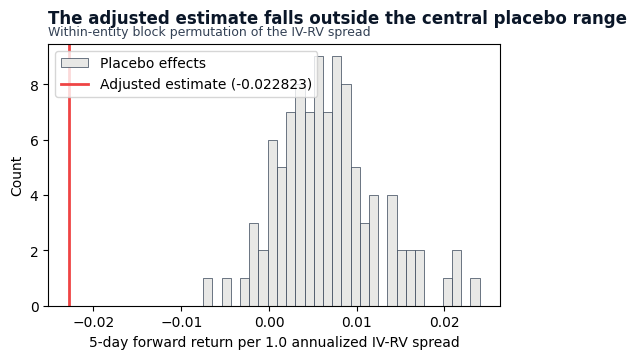

In [12]:
placebo_arr = np.array(ref.get("placebo_effects", []))
if len(placebo_arr) > 0:
    fig, ax = plt.subplots(figsize=FIGSIZE["single"])
    ax.hist(
        placebo_arr,
        bins=30,
        color=COLORS["silver_muted"],
        edgecolor=COLORS["neutral"],
        linewidth=0.5,
        label="Placebo effects",
    )
    ax.axvline(
        dml_effect,
        color=COLORS["negative"] if dml_effect < 0 else COLORS["positive"],
        linewidth=2,
        label=f"Adjusted estimate ({dml_effect:.6f})",
    )
    relation = "outside" if p_value_perm < 0.05 else "inside"
    add_message_title(
        ax,
        f"The adjusted estimate falls {relation} the central placebo range",
        subtitle="Within-entity block permutation of the IV-RV spread",
    )
    ax.set_xlabel("5-day forward return per 1.0 annualized IV-RV spread")
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()

## 5. Register Results

First align the out-of-fold residuals with the analysis panel and construct
the standardized per-observation artifact.

In [13]:
T_res = dml_result.get("T_res", np.full(len(merged_clean), np.nan))
Y_res = dml_result.get("Y_res", np.full(len(merged_clean), np.nan))

n_analysis = len(merged_clean)
if len(T_res) > n_analysis:
    T_res = T_res[-n_analysis:]
    Y_res = Y_res[-n_analysis:]

symbol_col = entity_cols[0] if entity_cols else None

predictions = pd.DataFrame(
    {
        "timestamp": pd.to_datetime(merged_clean[date_col]),
        "symbol": merged_clean[symbol_col].values if symbol_col else "ALL",
        "y_true": merged_clean[label_col].values,
        "treatment_value": merged_clean[TREATMENT_COL].values,
        "treatment_residual": T_res,
        "outcome_residual": Y_res,
        "treatment_contribution": T_res * dml_effect,
        "ate": dml_effect,
        "ate_se": se_hac,
    }
)

The compact summary carries the estimand, panel-aware uncertainty, and
refutation result into the registry.

In [14]:
summary = {
    "treatment": TREATMENT_COL,
    "outcome": label_col,
    "confounders": CONFOUNDER_COLS,
    "n_observations": dml_result["n_obs"],
    "n_decision_times": dml_result["n_periods"],
    "naive_effect": float(naive_effect),
    "dml_effect": float(dml_effect),
    "dml_se_iid": float(dml_result["se_iid"]),
    "dml_se_hac": float(se_hac),
    "confounding_bias_pct": float(bias_pct),
    "p_value_hac": float(p_value),
    "hac_maxlags": int(results.get("hac_maxlags", 0)),
    "covariance_type": dml_result["covariance_type"],
    "refutation_p_value": float(p_value_perm),
    "refutation_class": ref_class,
}

Registration writes only the corrected v3.1 candidate. The frozen v3.0
registry remains read-only for publication comparison.

In [15]:
register_causal_run(
    case_study_id=CASE_STUDY_ID,
    label=PRIMARY_LABEL,
    results=results,
    predictions=predictions,
    treatment_col=TREATMENT_COL,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    notebook="12_causal_dml",
)

  -> registered causal_dml (causal_hash=0ec42406f6d9, p_hac=0.2568)


'0ec42406f6d9'

## Key Takeaways

1. **The sealed holdout remains unused**: The analysis ends before the
   label-buffer cutoff, so exploratory causal diagnostics cannot influence or
   consume the final evaluation window.

2. **The adjusted association is not distinguishable from zero under panel
   uncertainty**: The DML estimate is -0.0228 units of five-day return per 1.0
   annualized IV-RV spread, with Driscoll-Kraay SE 0.0200 and p = 0.257.

3. **Observed confounders barely move the same-sample estimate**: Naive OLS is
   -0.022934 versus -0.022823 for DML, a -0.49% difference. Comparing both
   estimators on the same 38,422 out-of-fold rows removes the apparent large
   correction created by unequal samples.

4. **The permutation result is supporting, not decisive**: The 100-placebo,
   5-fold block-null p-value is 0.01, indicating unusual time alignment under
   that diagnostic. It does not override the panel-aware coefficient uncertainty.

5. **Diagnostics do not establish identification**: Complete-date cross-fitting
   and both uncertainty checks strengthen the sensitivity analysis, but a
   causal reading still requires conditional ignorability, overlap, and SUTVA.

**Next**: See the case-study insights notebook for comparison across all nine
case studies.

**Book**: Section 15.6 contrasts this with S&P 500 Options.

In [16]:
print(f"\nCausal DML registry summary: {CASE_STUDY_ID}")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print(f"\nCausal DML analysis complete for {CASE_STUDY_ID}")


Causal DML registry summary: sp500_equity_option_analytics
  treatment: ivrv_spread
  outcome: fwd_ret_5d
  confounders: ['rv_20', 'mom_21d', 'skew_rr_30_25d']
  n_observations: 38422
  n_decision_times: 98
  naive_effect: -0.022934
  dml_effect: -0.022823
  dml_se_iid: 0.002664
  dml_se_hac: 0.020006
  confounding_bias_pct: -0.486420
  p_value_hac: 0.256794
  hac_maxlags: 9
  covariance_type: driscoll_kraay
  refutation_p_value: 0.010000
  refutation_class: Passes

Causal DML analysis complete for sp500_equity_option_analytics
